In [5]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_monthly_summary.csv
/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_yearly_performance.csv
/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_historical_365days.csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")


In [7]:
file_path = "/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_historical_365days.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully.
Shape: (33364, 15)


,coin_id,coin_name,symbol,market_cap_rank,timestamp,date,price,market_cap,volume,daily_return,price_ma7,price_ma30,volatility_7d,cumulative_return,month
0,aave,Aave,AAVE,46,2024-12-04 00:00:00,2024-12-04,241.886714,3.633154e+09,1.181708e+09,NaN,241.886714,241.886714,NaN,NaN,2024-12
1,aave,Aave,AAVE,46,2024-12-05 00:00:00,2024-12-05,255.966610,3.841768e+09,1.191179e+09,5.820864,248.926662,248.926662,NaN,5.820864,2024-12
2,aave,Aave,AAVE,46,2024-12-06 00:00:00,2024-12-06,248.589404,3.725870e+09,8.706666e+08,-2.882097,248.814243,248.814243,6.153922,2.771004,2024-12
3,aave,Aave,AAVE,46,2024-12-07 00:00:00,2024-12-07,281.755167,4.226339e+09,1.120551e+09,13.341583,257.049474,257.049474,8.119016,16.482283,2024-12
4,aave,Aave,AAVE,46,2024-12-08 00:00:00,2024-12-08,282.398618,4.241226e+09,6.553344e+08,0.228372,262.119303,262.119303,7.120498,16.748297,2024-12


RQ5 Correlation Matrix:


,price,volume,daily_return,price_change_pct
price,1.0000,0.1828,0.0020,-0.0007
volume,0.1828,1.0000,0.0015,-0.0020
daily_return,0.0020,0.0015,1.0000,-0.0299
price_change_pct,-0.0007,-0.0020,-0.0299,1.0000


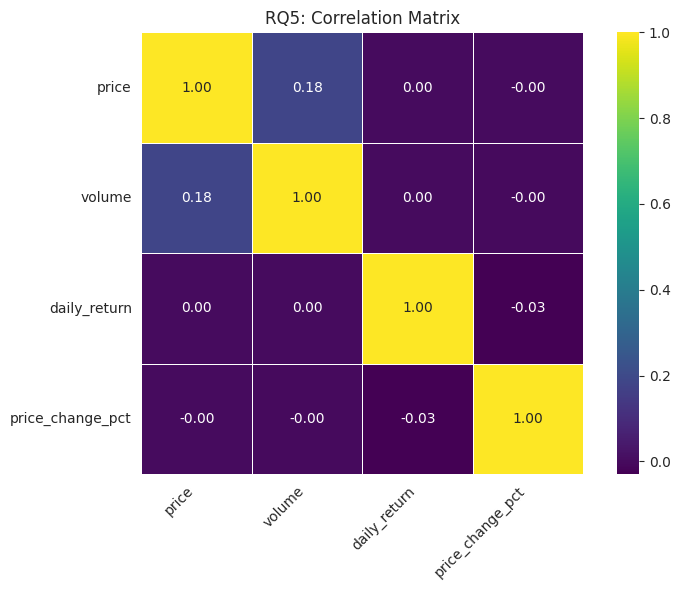

In [11]:
# RQ5: What is the relationship between trading volume and price movements?
# Heatmap style figure like the sample image

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_historical_365days.csv"

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.lower().str.strip()
df["date"] = pd.to_datetime(df["date"])

# Sort properly before creating next-day movement
df = df.sort_values(["coin_id", "date"]).reset_index(drop=True)

# Create price movement variables
df["next_day_price"] = df.groupby("coin_id")["price"].shift(-1)
df["price_change"] = df["next_day_price"] - df["price"]
df["price_change_pct"] = (df["price_change"] / df["price"]) * 100

# Remove rows where next-day price is missing
df = df.dropna(subset=["next_day_price"]).copy()

# Select variables for correlation analysis
rq5_df = df[["price", "volume", "daily_return", "price_change_pct"]].copy()

# Correlation matrix table
corr_df = rq5_df.corr().round(4)
corr_df.to_csv("/kaggle/working/RQ5_correlation_matrix.csv")

print("RQ5 Correlation Matrix:")
display(corr_df)

# Heatmap figure
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_df,
    annot=True,
    cmap="viridis",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar=True
)

plt.title("RQ5: Correlation Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("/kaggle/working/RQ5_correlation_heatmap.pdf")
plt.show()
